<a href="https://colab.research.google.com/github/si-janenunes/CURSO-IA-CETAM-2026/blob/main/ModuloII_Exercicio_aula3_2parte.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Experimentos guiados com o dataset Breast Cancer — TensorFlow/Keras

# Experimento 1 - Rede Neural sem técnicas de generalização

# Célula 3 — CÓDIGO

In [1]:
#Importar as bibliotecas
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# CÉLULA 4 — CÓDIGO

In [2]:
#Carregar DataSet

dados = load_breast_cancer()
X = dados.data
y = dados.target
print("Quantidade de amostras:", X.shape[0])
print("Quantidade de características:", X.shape[1])
print("Classes:", dados.target_names)

Quantidade de amostras: 569
Quantidade de características: 30
Classes: ['malignant' 'benign']


Temos 30 entradas (features) para a rede neural e uma saída binária (malignant&#39; &#39;benign)


# CÉLULA 6 — CÓDIGO

In [3]:
#Transformar em DataFrame

df = pd.DataFrame(X, columns=dados.feature_names)
df["classe"] = y
df.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,classe
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


# CÉLULA 7 — CÓDIGO

In [4]:
#Verificar os dados

print(df.shape)
print("\nValores ausentes:\n")
print(df.isnull().sum())
print("\nDistribuição das classes:\n")
print(df["classe"].value_counts())

(569, 31)

Valores ausentes:

mean radius                0
mean texture               0
mean perimeter             0
mean area                  0
mean smoothness            0
mean compactness           0
mean concavity             0
mean concave points        0
mean symmetry              0
mean fractal dimension     0
radius error               0
texture error              0
perimeter error            0
area error                 0
smoothness error           0
compactness error          0
concavity error            0
concave points error       0
symmetry error             0
fractal dimension error    0
worst radius               0
worst texture              0
worst perimeter            0
worst area                 0
worst smoothness           0
worst compactness          0
worst concavity            0
worst concave points       0
worst symmetry             0
worst fractal dimension    0
classe                     0
dtype: int64

Distribuição das classes:

classe
1    357
0    212
Name:

# CÉLULA 8 — CÓDIGO

In [5]:
#Separar TESTE

X_train_val, X_test, y_train_val, y_test = train_test_split(
X,
y,
test_size=0.20, #Reservamos 20% para teste.
random_state=42, #Use uma sequência aleatória, mas sempre reproduza a mesma sequência
stratify=y
)

# CÉLULA 9 — CÓDIGO

In [6]:
#Separar TRAIN e VALIDATION

X_train, X_val, y_train, y_val = train_test_split(
X_train_val,
y_train_val,
test_size=0.20,
random_state=42, #Para garantir a reprodutibilidade dos resultados.
stratify=y_train_val
)

# CÉLULA 10 — CÓDIGO

In [7]:
#conferindo

print("Train: ", X_train.shape)
print("Validation: ", X_val.shape)
print("Test: ", X_test.shape)

Train:  (364, 30)
Validation:  (91, 30)
Test:  (114, 30)


# CÉLULA 11 — CÓDIGO

In [8]:
#Normalização

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

Por que usamos fit_transform() somente no Train?

Porque os parâmetros da normalização —

como média e desvio-padrão — devem ser
aprendidos somente com o conjunto de treinamento.

Depois usamos: transform() em Validation e Test.

Assim evitamos vazamento de dados (data leakage).

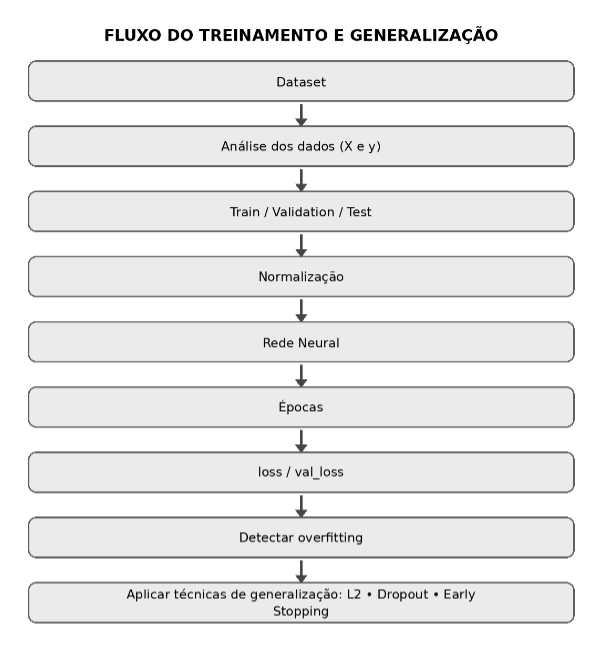

# CÉLULA 14 — CÓDIGO

In [9]:
model = keras.Sequential([
layers.Input(shape=(30,)),
layers.Dense(128, activation="relu"),
layers.Dense(64, activation="relu"),
layers.Dense(32, activation="relu"),
layers.Dense(1, activation="sigmoid")
])

# CÉLULA 15 — CÓDIGO

In [10]:
model.compile(
optimizer="adam", #ajusta os pesos
loss="binary_crossentropy", # mede o erro
metrics=["accuracy"] # mede a porcentagem de acertos
)
history = model.fit( #guarda o resultado dos valores
X_train,
y_train,
validation_data=(X_val, y_val),
epochs=200,
batch_size=16
)
#X contém as 30 características e y contém a resposta correta (0 ou 1).

Epoch 1/200
23/23 ━━━━━━━━━━━━━━━━━━━━ 5s 55ms/step - accuracy: 0.8984 - loss: 0.4128 - val_accuracy: 0.9560 - val_loss: 0.2195
Epoch 2/200
23/23 ━━━━━━━━━━━━━━━━━━━━ 2s 45ms/step - accuracy: 0.9643 - loss: 0.1277 - val_accuracy: 0.9780 - val_loss: 0.0946
Epoch 3/200
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 53ms/step - accuracy: 0.9780 - loss: 0.0677 - val_accuracy: 0.9780 - val_loss: 0.0857
Epoch 4/200
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - accuracy: 0.9890 - loss: 0.0503 - val_accuracy: 0.9780 - val_loss: 0.0755
Epoch 5/200
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - accuracy: 0.9918 - loss: 0.0429 - val_accuracy: 0.9780 - val_loss: 0.0735
Epoch 6/200
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - accuracy: 0.9918 - loss: 0.0314 - val_accuracy: 0.9780 - val_loss: 0.0748
Epoch 7/200
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - accuracy: 0.9918 - loss: 0.0258 - val_accuracy: 0.9780 - val_loss: 0.0712
Epoch 8/200
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - accuracy: 0.9945 - loss: 0.0217 - val_accuracy: 0.

# CÉLULA 16 — CÓDIGO

In [11]:
print(history.history.keys())

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])


loss → erro no treino
val_loss → erro na validação
accuracy → acurácia no treino
val_accuracy → acurácia na validação

# CÉLULA 18 — CÓDIGO

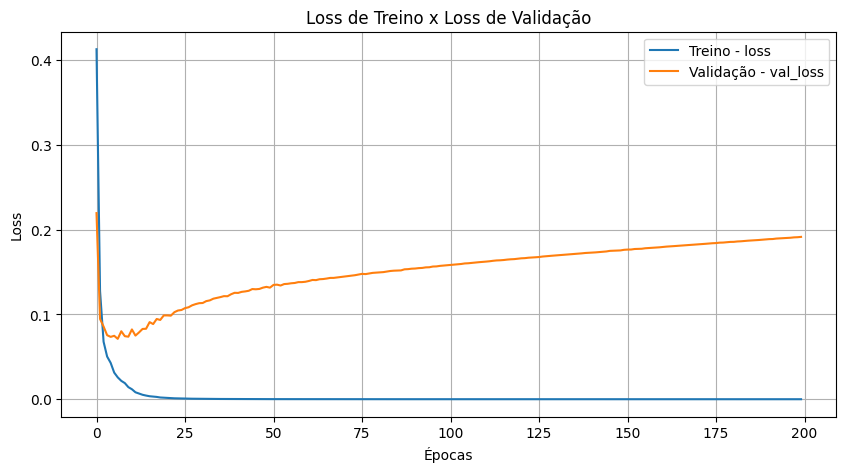

In [12]:
#Gráfico loss × val_loss

import matplotlib.pyplot as plt
plt.figure(figsize=(10, 5))
plt.plot(history.history['loss'], label='Treino - loss')
plt.plot(history.history['val_loss'], label='Validação - val_loss')
plt.xlabel('Épocas')
plt.ylabel('Loss')
plt.title('Loss de Treino x Loss de Validação')
plt.legend()
plt.grid()
plt.show()

Nós mandamos a rede treinar por 200 épocas.

Mas em qual época ela realmente apresentou o
melhor resultado de validação?

# CÉLULA 20 — CÓDIGO

In [13]:
#Descobrir automaticamente a melhor época

import numpy as np
melhor_epoca = np.argmin(history.history["val_loss"]) + 1
menor_val_loss = np.min(history.history["val_loss"])
print("Melhor época:", melhor_epoca)
print("Menor val_loss:", menor_val_loss)

Melhor época: 7
Menor val_loss: 0.07118459790945053


Imagine se tivessemos o Early Stopping com patience=5

Época 4 → melhor resultado

Época 5 → não melhorou 1

Época 6 → não melhorou 2

Época 7 → não melhorou 3

Época 8 → não melhorou 4

Época 9 → não melhorou 5

��

EARLY STOPPING

# CÉLULA 22 — CÓDIGO

In [14]:
restore_best_weights=True

# EXPERIMENTO 2 — REDE NEURAL COM EARLY STOPPING

Vamos repetir o mesmo experimento do zero, mas agora acrescentando uma técnica para

controlar o overfitting.

E não precisa carregar o dataset novamente nem fazer novamente Train/Validation/Test ou

normalização

# CÉLULA 25 — CÓDIGO

In [15]:
#Criando uma nova rede neural

model_early = keras.Sequential([
# A rede recebe as 30 características do dataset

layers.Input(shape=(30,)),
# Primeira camada oculta

layers.Dense(128, activation="relu"),
# Segunda camada oculta

layers.Dense(64, activation="relu"),

    # Terceira camada oculta
layers.Dense(32, activation="relu"),
# Camada de saída

# Sigmoid porque temos classificação binária: 0 ou 1
layers.Dense(1, activation="sigmoid")
])
model_early.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 128)            │         3,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,337 (56.00 KB)

 Trainable params: 14,337 (56.00 KB)

 Non-trainable params: 0 (0.00 B)

# CÉLULA 26 — CÓDIGO

In [16]:
# Compilando a Rede Neural

model_early.compile(
# Algoritmo que ajustará os pesos
optimizer="adam",

# Função de erro para classificação binária

loss="binary_crossentropy",
# Métrica que também queremos acompanhar

metrics=["accuracy"]
)

# CÉLULA 27 — CÓDIGO

In [17]:
# Criando o Early Stopping

early_stop = keras.callbacks.EarlyStopping(
# Observe o erro da VALIDAÇÃO

monitor="val_loss",

# Aguarde 5 épocas sem melhora
patience=5,

# Ao terminar, volte para os melhores pesos encontrados
restore_best_weights=True
)

Patience determina quanto tempo esperamos antes de parar.

Early Stopping determina quando interromper.

restore_best_weights=True faz a rede voltar aos melhores pesos encontrados durante esse treinamento.

# CÉLULA 29 — CÓDIGO

In [18]:
# Treinando a nova Rede Neural

history_early = model_early.fit(
# Dados utilizados para APRENDER

X_train,
y_train,

# Dados utilizados para acompanhar a generalização
validation_data=(X_val, y_val),

  # Número MÁXIMO de épocas
epochs=200,

# Quantidade de exemplos processados antes
# de uma atualização dos pesos

batch_size=16,

# Aqui ativamos o Early Stopping que irá acompanhar o treinamento
callbacks=[early_stop]
)

Epoch 1/200
23/23 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 0.8681 - loss: 0.4103 - val_accuracy: 0.9011 - val_loss: 0.2151
Epoch 2/200
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9615 - loss: 0.1213 - val_accuracy: 0.9780 - val_loss: 0.0920
Epoch 3/200
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9725 - loss: 0.0714 - val_accuracy: 0.9780 - val_loss: 0.0726
Epoch 4/200
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9863 - loss: 0.0505 - val_accuracy: 0.9780 - val_loss: 0.0705
Epoch 5/200
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9918 - loss: 0.0394 - val_accuracy: 0.9780 - val_loss: 0.0654
Epoch 6/200
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9918 - loss: 0.0320 - val_accuracy: 0.9780 - val_loss: 0.0711
Epoch 7/200
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9945 - loss: 0.0246 - val_accuracy: 0.9780 - val_loss: 0.0674
Epoch 8/200
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9945 - loss: 0.0202 - val_accuracy: 0.9670 - 

# CÉLULA 30 — CÓDIGO

In [19]:
# Descobrindo quantas épocas realmente foram executadas

epocas_executadas = len(history_early.history["loss"])
print("Máximo permitido: 200 épocas")

print("Épocas realmente executadas:", epocas_executadas)

Máximo permitido: 200 épocas
Épocas realmente executadas: 10


# CÉLULA 31 — CÓDIGO

In [20]:
# Localiza o menor val_loss

melhor_epoca = np.argmin(history_early.history["val_loss"]) + 1

# Recupera o valor do menor val_loss
menor_val_loss = np.min(history_early.history["val_loss"])

print("Melhor época: ", melhor_epoca)
print("Menor val_loss: ", menor_val_loss)

Melhor época:  5
Menor val_loss:  0.06544491648674011


# CÉLULA 32 — CÓDIGO

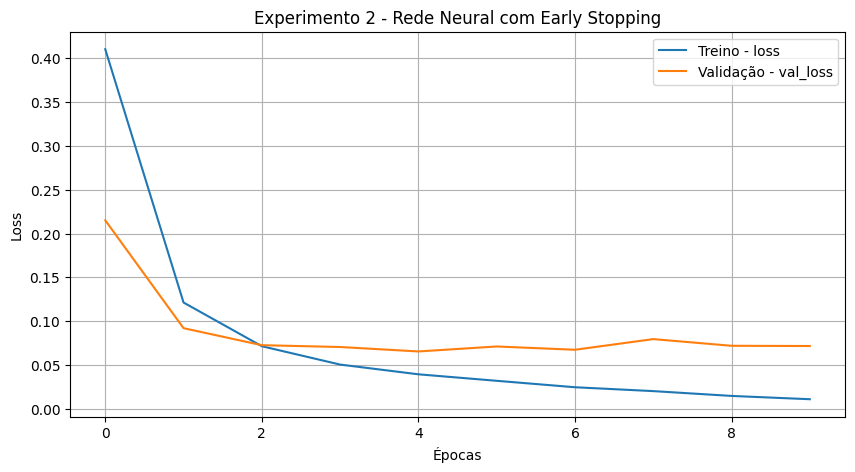

In [21]:
# Gráfico Experimento 2 - Rede Neural com Early Stopping

plt.figure(figsize=(10, 5))
plt.plot(
history_early.history["loss"],
label="Treino - loss"
)
plt.plot(
history_early.history["val_loss"],
label="Validação - val_loss"
)
plt.xlabel("Épocas")
plt.ylabel("Loss")
plt.title(
"Experimento 2 - Rede Neural com Early Stopping"
)
plt.legend()
plt.grid()
plt.show()

# CÉLULA 33 — CÓDIGO

In [22]:
# Avaliação final com dados de TESTE

test_loss, test_accuracy = model_early.evaluate(
X_test,
y_test,
verbose=0
)
print("Loss no teste: ", test_loss)
print("Accuracy no teste: ", test_accuracy)

Loss no teste:  0.10986314713954926
Accuracy no teste:  0.9473684430122375


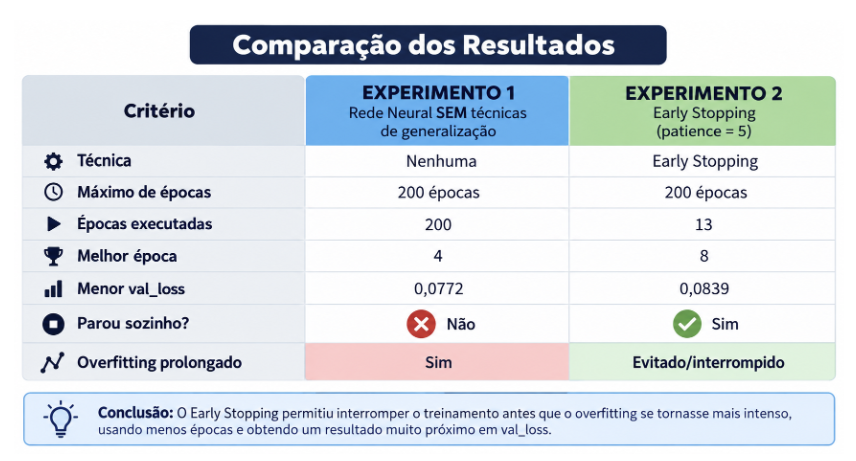

As redes começam com pesos inicializados aleatoriamente e o treinamento também pode
envolver aleatoriedade. Portanto, uma execução não precisa produzir exatamente o mesmo
melhor val_loss da outra.
O objetivo do experimento não é provar que Early Stopping sempre produz um número menor.
É mostrar que:
Early Stopping impede que continuemos treinando desnecessariamente depois que a
validação deixou de melhorar.

# EXPERIMENTO 3 — REDE NEURAL COM REGULARIZAÇÃO L2

O L2 acrescenta uma penalização para pesos grandes.
Continue aprendendo, mas evite depender excessivamente de pesos muito grandes

# CÉLULA 36 — CÓDIGO

In [23]:
#Importar o regularizador L2

from tensorflow.keras.regularizers import l2

# CÉLULA 37 — CÓDIGO

In [24]:
#Criar uma NOVA rede

model_l2 = keras.Sequential([
# 30 características de entrada

layers.Input(shape=(30,)),
# L2 aplicado aos pesos desta camada

layers.Dense(
128,
activation="relu",
kernel_regularizer=l2(0.001)
),

# L2 aplicado aos pesos desta camada
layers.Dense(
64,
activation="relu",
kernel_regularizer=l2(0.001)
),
# L2 aplicado aos pesos desta camada
layers.Dense(
32,
activation="relu",
kernel_regularizer=l2(0.001)
),
# Saída binária
layers.Dense(
1,
activation="sigmoid")
])
model_l2.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_8 (Dense)                 │ (None, 128)            │         3,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,337 (56.00 KB)

 Trainable params: 14,337 (56.00 KB)

 Non-trainable params: 0 (0.00 B)

# CÉLULA 38 — CÓDIGO

In [25]:
kernel_regularizer=l2(0.001) ## L2: penaliza pesos grandes; 0.001 define a
#  intensidade dessa penalização

# CÉLULA 39 — CÓDIGO

In [26]:
#Compilar

model_l2.compile(
optimizer="adam",
loss="binary_crossentropy",
metrics=["accuracy"]
)

# CÉLULA 40 — CÓDIGO

In [27]:
# Treinar 200 epocas

history_l2 = model_l2.fit(
X_train,
y_train,
validation_data=(X_val, y_val),
epochs=200,
batch_size=16
)

Epoch 1/200
23/23 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - accuracy: 0.9286 - loss: 0.5682 - val_accuracy: 0.9560 - val_loss: 0.3563
Epoch 2/200
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9588 - loss: 0.3031 - val_accuracy: 0.9670 - val_loss: 0.2600
Epoch 3/200
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9835 - loss: 0.2349 - val_accuracy: 0.9780 - val_loss: 0.2399
Epoch 4/200
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9918 - loss: 0.2106 - val_accuracy: 0.9670 - val_loss: 0.2367
Epoch 5/200
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9918 - loss: 0.1904 - val_accuracy: 0.9780 - val_loss: 0.2281
Epoch 6/200
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9918 - loss: 0.1782 - val_accuracy: 0.9670 - val_loss: 0.2215
Epoch 7/200
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9918 - loss: 0.1651 - val_accuracy: 0.9780 - val_loss: 0.2116
Epoch 8/200
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9918 - loss: 0.1550 - val_accuracy: 0.9780 - 

# CÉLULA 41 — CÓDIGO

In [28]:
#Encontrar a melhor epoca

melhor_epoca_l2 = np.argmin(
history_l2.history["val_loss"]
) + 1
menor_val_loss_l2 = np.min(
history_l2.history["val_loss"]
)
print("Melhor época: ", melhor_epoca_l2)
print("Menor val_loss: ", menor_val_loss_l2)

Melhor época:  154
Menor val_loss:  0.07623491436243057


# CÉLULA 42 — CÓDIGO

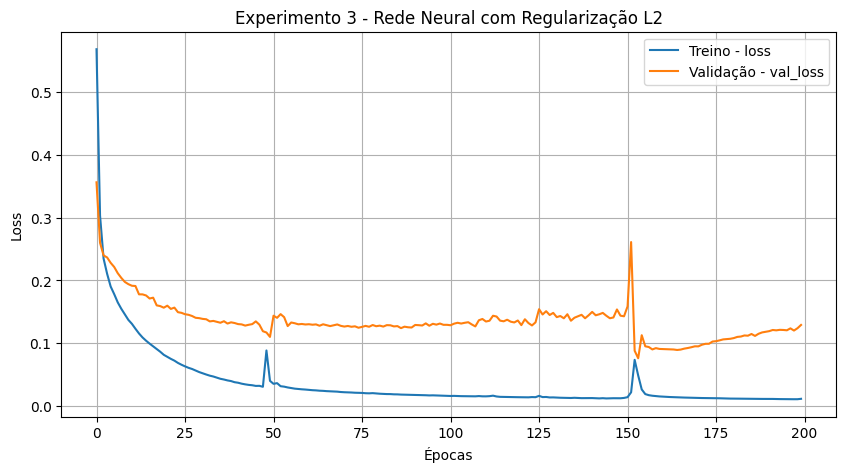

In [29]:
#Grafico Experimento 3 - Rede Neural com Regularização L2

plt.figure(figsize=(10, 5))
plt.plot(
history_l2.history["loss"],
label="Treino - loss"
)
plt.plot(
history_l2.history["val_loss"],
label="Validação - val_loss"
)
plt.xlabel("Épocas")
plt.ylabel("Loss")
plt.title(

"Experimento 3 - Rede Neural com Regularização L2"
)
plt.legend()
plt.grid()
plt.show()

1. O loss continua chegando praticamente a zero?
2. loss e val_loss continuam se afastando?
3. Qual foi a melhor época?
4. O val_loss começou a subir depois dela?
5. O L2 eliminou o overfitting ou apenas o reduziu?

No Experimento 1, sem regularização, a rede rapidamente levou o loss de treinamento para
praticamente zero e o val_loss começou a crescer cedo.

Com L2, o treinamento ficou mais restrito.
A rede continua aprendendo, mas existe uma
penalização sobre os pesos:

O val_loss atingiu o menor valor na época 148, cerca de: 0,0922
Depois voltou a crescer.

Então, mesmo utilizando L2, ainda podemos observar sinais de overfitting após a melhor
região de validação.

ou seja,
L2 pode reduzir o overfitting, mas não garante que ele desapareça.

# CÉLULA 45 — CÓDIGO

In [30]:
#Teste

test_loss_l2, test_accuracy_l2 = model_l2.evaluate(
X_test,
y_test,
verbose=0
)
print("Loss no teste: ", test_loss_l2)
print("Accuracy no teste: ", test_accuracy_l2)

Loss no teste:  0.11894554644823074
Accuracy no teste:  0.9736841917037964


# EXPERIMENTO 4 — REDE NEURAL COM DROPOUT

# CÉLULA 47 — CÓDIGO

In [31]:
# Criando uma NOVA rede neural.
# Sequential significa que as camadas serão executadas
# uma depois da outra, em sequência.

model_dropout = keras.Sequential([
# Camada de entrada.
# Nosso dataset possui 30 características (features).
# Portanto, cada amostra entra na rede com 30 valores.

layers.Input(shape=(30,)),
# Primeira camada oculta.
# Possui 128 neurônios.
# ReLU é a função de ativação utilizada.

layers.Dense(
128,
activation="relu"
),
# DROPOUT:
# Durante o TREINAMENTO, 30% das ativações
# desta camada serão zeradas aleatoriamente.

 layers.Dropout(0.30),

# Segunda camada oculta.
# Possui 64 neurônios com função de ativação ReLU.

layers.Dense(
64,
activation="relu"
),

# Novamente aplicamos Dropout de 30%.
layers.Dropout(0.30),

# Terceira camada oculta.
# Possui 32 neurônios.

layers.Dense(
32,
activation="relu"
),

# Camada de saída.
# Temos apenas 1 neurônio porque nosso problema
# é uma classificação binária.

# sigmoid produz um valor entre 0 e 1.
layers.Dense(
1,
activation="sigmoid"
)
])
# Mostra a arquitetura da rede criada.
model_dropout.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_12 (Dense)                │ (None, 128)            │         3,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,337 (56.00 KB)

 Trainable params: 14,337 (56.00 KB)

 Non-trainable params: 0 (0.00 B)

# CÉLULA 48 — CÓDIGO

In [32]:
# ============================================================
# COMPILAÇÃO DO MODELO
# ============================================================
model_dropout.compile(
# OPTIMIZER:
# Adam é o algoritmo que realizará as atualizações
# dos pesos da rede durante o treinamento.

optimizer="adam",
# LOSS:
# Binary Crossentropy é utilizada porque temos
# um problema de classificação BINÁRIA.

# Nosso alvo possui duas possibilidades:
# 0 ou 1.

loss="binary_crossentropy",
# METRICS:
# Além do loss, queremos acompanhar também
# a porcentagem de classificações corretas.

 metrics=["accuracy"]
)

# CÉLULA 49 — CÓDIGO

In [33]:
# ============================================================
# TREINAMENTO
# ============================================================

history_dropout = model_dropout.fit(
# X_train contém as características utilizadas
# para o treinamento da rede.

X_train,
# y_train contém as respostas corretas
# correspondentes ao X_train.

y_train,
# A cada época, o Keras também avaliará
# o modelo utilizando os dados de VALIDAÇÃO.
#
# Esses dados NÃO são utilizados para ajustar
# diretamente os pesos.

validation_data=(X_val, y_val),
# Permitimos que a rede treine durante
# 200 épocas completas.

epochs=200,
# A rede processará 16 amostras antes
# de realizar uma atualização dos pesos.

batch_size=16
)

Epoch 1/200
23/23 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - accuracy: 0.8434 - loss: 0.4883 - val_accuracy: 0.9560 - val_loss: 0.2540
Epoch 2/200
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9478 - loss: 0.2056 - val_accuracy: 0.9780 - val_loss: 0.1185
Epoch 3/200
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9753 - loss: 0.1043 - val_accuracy: 0.9780 - val_loss: 0.0846
Epoch 4/200
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9808 - loss: 0.0748 - val_accuracy: 0.9780 - val_loss: 0.0749
Epoch 5/200
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9808 - loss: 0.0728 - val_accuracy: 0.9780 - val_loss: 0.0691
Epoch 6/200
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9863 - loss: 0.0577 - val_accuracy: 0.9780 - val_loss: 0.0679
Epoch 7/200
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9890 - loss: 0.0454 - val_accuracy: 0.9780 - val_loss: 0.0679
Epoch 8/200
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9918 - loss: 0.0389 - val_accuracy: 0.9780 -

# CÉLULA 50 — CÓDIGO

In [34]:
# ============================================================
# QUANTIDADE DE ÉPOCAS EXECUTADAS
# ============================================================

# history_dropout.history[&#39;loss&#39;] contém um valor
# de loss para cada época executada.

# len() conta quantos valores existem nessa lista.

epocas_executadas_dropout = len(
history_dropout.history["loss"]
)
print(
"Épocas executadas: ",
epocas_executadas_dropout
)

Épocas executadas:  200


# CÉLULA 51 — CÓDIGO

In [35]:
# ============================================================
# LOCALIZAR A MELHOR ÉPOCA
# ============================================================

# np.argmin() procura a POSIÇÃO onde ocorreu
# o menor valor de val_loss.

# Somamos +1 porque o Python começa a contar
# as posições a partir de zero.

melhor_epoca_dropout = (
np.argmin(history_dropout.history["val_loss"]) + 1
)
# np.min() recupera diretamente o MENOR
# valor encontrado em val_loss.

menor_val_loss_dropout = np.min(
history_dropout.history["val_loss"]
)
print(
"Melhor época: ",
melhor_epoca_dropout
)
print(
"Menor val_loss: ",
menor_val_loss_dropout
)

Melhor época:  9
Menor val_loss:  0.0621790736913681


# CÉLULA 52 — CÓDIGO

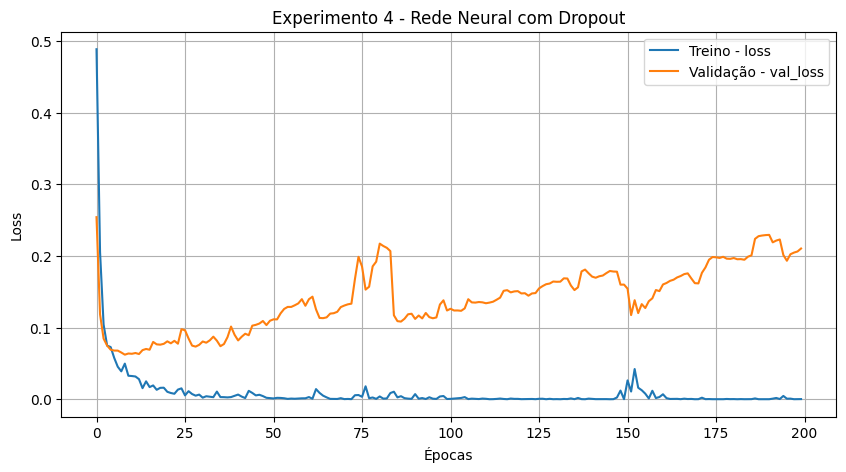

In [36]:
# ============================================================
# GRÁFICO DO TREINAMENTO
# ============================================================

# Criamos uma figura com tamanho 10 x 5.
plt.figure(figsize=(10, 5))

# Linha do LOSS de treinamento.

# Cada posição da lista representa uma época.
plt.plot(
history_dropout.history["loss"],
label="Treino - loss"
)

# Linha do LOSS de validação.

# É esta curva que utilizamos para acompanhar
# a capacidade de generalização.

plt.plot(
history_dropout.history["val_loss"],
label="Validação - val_loss"
)

# Nome do eixo horizontal.
plt.xlabel("Épocas")
# Nome do eixo vertical.
plt.ylabel("Loss")

# Título do gráfico.
plt.title(
"Experimento 4 - Rede Neural com Dropout"
)

# Mostra a legenda das duas curvas.
plt.legend()

# Adiciona linhas de grade para facilitar
# a leitura do gráfico.
plt.grid()
# Exibe o gráfico.
plt.show()

Perto das 200 épocas, o loss de treinamento está praticamente em zero, enquanto o val_loss
chega perto de 0,25.

Isso é overfitting muito evidente.

# CÉLULA 54 — CÓDIGO

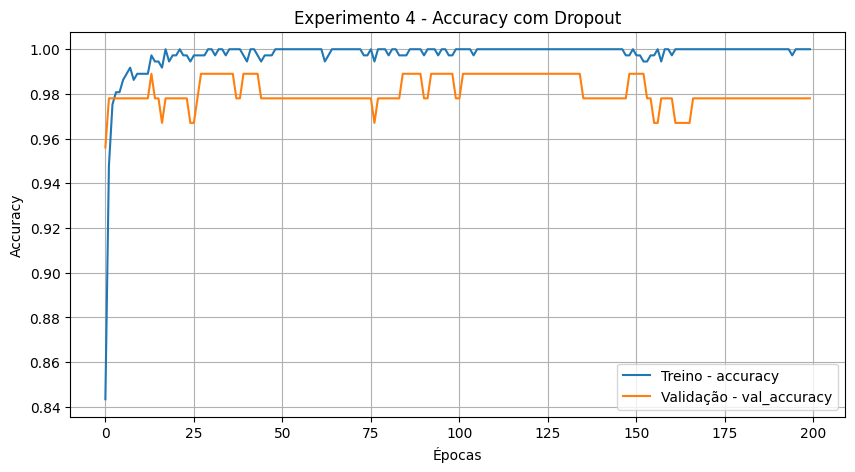

In [37]:
# ============================================================
# GRÁFICO DE ACCURACY
# ============================================================

plt.figure(figsize=(10, 5))
# Accuracy nos dados utilizados para treinamento.

plt.plot(
history_dropout.history["accuracy"],
label="Treino - accuracy"
)

# Accuracy nos dados de validação.
plt.plot(
history_dropout.history["val_accuracy"],
label="Validação - val_accuracy"
)

plt.xlabel("Épocas")
plt.ylabel("Accuracy")
plt.title(
"Experimento 4 - Accuracy com Dropout"
)
plt.legend()
plt.grid()
plt.show()

# CÉLULA 55 — CÓDIGO

In [38]:
# ============================================================
# AVALIAÇÃO FINAL NO CONJUNTO DE TESTE
# ============================================================

# evaluate() apresenta ao modelo dados que ficaram
# separados do treinamento.

# X_test = características
# y_test = respostas corretas

test_loss_dropout, test_accuracy_dropout = (
model_dropout.evaluate(
X_test,
y_test,

# verbose=0 evita imprimir a barra
# de progresso da avaliação.

verbose=0
)
)
print(
"Loss no teste: ",
test_loss_dropout
)
print(
"Accuracy no teste: ",
test_accuracy_dropout
)

Loss no teste:  0.2993994355201721
Accuracy no teste:  0.9649122953414917


# EXPERIMENTO 5 — COMBINAÇÃO DE L2 + DROPOUT + EARLY
# STOPPING

Queremos que:
L2 controle o crescimento dos pesos;

Dropout dificulte a dependência excessiva das mesmas ativações;

Early Stopping acompanhe o val_loss;

Patience dê uma margem para novas melhoras; e restore_best_weights=True deixe o modelo final com os melhores pesos observados

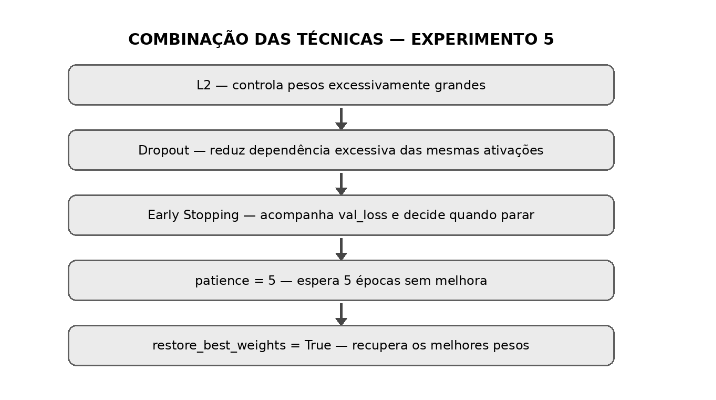

# CÉLULA 58 — CÓDIGO

In [39]:
# ============================================================
# EXPERIMENTO 5
# L2 + DROPOUT + EARLY STOPPING
# ============================================================

# Criamos uma NOVA rede neural.
# Ela começará novamente com novos pesos.

model_final = keras.Sequential([
# Entrada:
# nosso dataset possui 30 características.

layers.Input(shape=(30,)),

# --------------------------------------------------------
# PRIMEIRA CAMADA OCULTA
# --------------------------------------------------------

# 128 neurônios com função de ativação ReLU.

# kernel_regularizer=l2(0.001)
# aplica regularização L2 aos pesos desta camada.

layers.Dense(
128,
activation="relu",
kernel_regularizer=l2(0.001)
),
# Durante o treinamento, 30% das ativações
# serão zeradas aleatoriamente.
layers.Dropout(0.30),

# --------------------------------------------------------
# SEGUNDA CAMADA OCULTA
# --------------------------------------------------------

layers.Dense(
64,
activation="relu",
kernel_regularizer=l2(0.001)
),
# Novamente aplicamos Dropout de 30%.
layers.Dropout(0.30),

# --------------------------------------------------------
# TERCEIRA CAMADA OCULTA
# --------------------------------------------------------
layers.Dense(
32,
activation="relu",
kernel_regularizer=l2(0.001)
),

# --------------------------------------------------------
# CAMADA DE SAÍDA
# --------------------------------------------------------

# Um neurônio com Sigmoid porque estamos
# fazendo classificação binária.

layers.Dense(
1,
activation="sigmoid"
)
])
# Exibe a arquitetura da rede.

model_final.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_16 (Dense)                │ (None, 128)            │         3,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,337 (56.00 KB)

 Trainable params: 14,337 (56.00 KB)

 Non-trainable params: 0 (0.00 B)

# CÉLULA 59 — CÓDIGO

In [40]:
# ============================================================
# EARLY STOPPING
# ============================================================

early_stop_final = keras.callbacks.EarlyStopping(

# Acompanhar o erro nos dados de validação.

monitor="val_loss",
# Queremos que val_loss DIMINUA.

mode="min",
# Aguarda 5 épocas consecutivas sem uma nova melhora.

patience=5,
# Ao parar, recupera os pesos correspondentes
# ao melhor val_loss encontrado.

restore_best_weights=True
)

# CÉLULA 60 — CÓDIGO

In [41]:
# ============================================================
# TREINAMENTO
# ============================================================

# Compilando o modelo
model_final.compile(
optimizer="adam",
loss="binary_crossentropy",
metrics=["accuracy"]
)
history_final = model_final.fit(
# Dados utilizados para aprender.

X_train,
y_train,

# Dados utilizados para acompanhar
# a capacidade de generalização.

validation_data=(X_val, y_val),
# Número MÁXIMO de épocas.

epochs=200,
# Processa 16 amostras antes
# de atualizar os pesos.

batch_size=16,
# Ativa o Early Stopping.
callbacks=[early_stop_final]
)

Epoch 1/200
23/23 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - accuracy: 0.8022 - loss: 0.6610 - val_accuracy: 0.9121 - val_loss: 0.4626
Epoch 2/200
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9368 - loss: 0.3878 - val_accuracy: 0.9670 - val_loss: 0.3079
Epoch 3/200
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9670 - loss: 0.2836 - val_accuracy: 0.9780 - val_loss: 0.2596
Epoch 4/200
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9835 - loss: 0.2455 - val_accuracy: 0.9780 - val_loss: 0.2423
Epoch 5/200
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9863 - loss: 0.2298 - val_accuracy: 0.9780 - val_loss: 0.2366
Epoch 6/200
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9863 - loss: 0.2225 - val_accuracy: 0.9780 - val_loss: 0.2297
Epoch 7/200
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9835 - loss: 0.2169 - val_accuracy: 0.9670 - val_loss: 0.2327
Epoch 8/200
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9780 - loss: 0.2083 - val_accuracy: 0.9670 

# CÉLULA 61 — CÓDIGO

In [42]:
# ============================================================
# QUANTIDADE DE ÉPOCAS EXECUTADAS
# ============================================================

epocas_final = len(
history_final.history["loss"]
)
print("Máximo permitido: 200")
print("Épocas realmente executadas: ", epocas_final)

Máximo permitido: 200
Épocas realmente executadas:  42


# CÉLULA 62 — CÓDIGO

In [43]:
# ============================================================
# MELHOR ÉPOCA
# ============================================================

melhor_epoca_final = (
np.argmin(history_final.history["val_loss"]) + 1
)
menor_val_loss_final = np.min(
history_final.history["val_loss"]
)
print("Melhor época: ", melhor_epoca_final)
print("Menor val_loss: ", menor_val_loss_final)

Melhor época:  37
Menor val_loss:  0.13731592893600464


# CÉLULA 63 — CÓDIGO

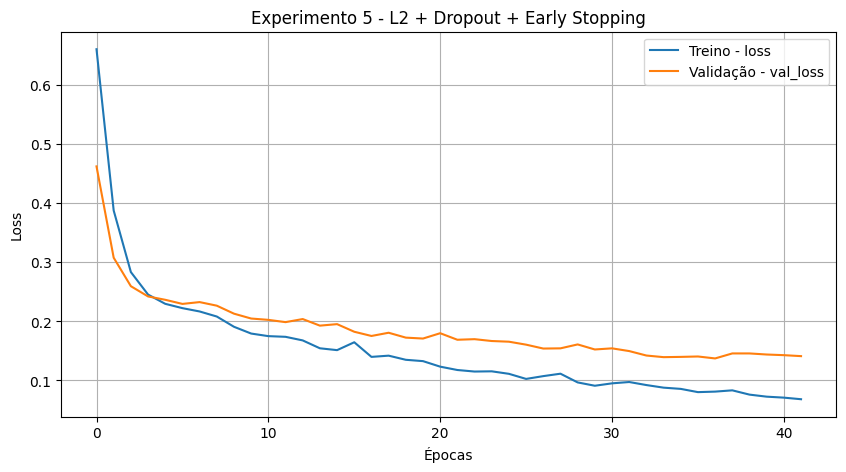

In [44]:
# ============================================================
# GRÁFICO LOSS x VAL_LOSS
# ============================================================

plt.figure(figsize=(10, 5))
# Erro nos dados de treinamento.

plt.plot(
history_final.history["loss"],
label="Treino - loss"
)

# Erro nos dados de validação.

plt.plot(
history_final.history["val_loss"],
label="Validação - val_loss"
)
plt.xlabel("Épocas")
plt.ylabel("Loss")
plt.title(
"Experimento 5 - L2 + Dropout + Early Stopping"
)
plt.legend()
plt.grid()
plt.show()

# CÉLULA 64 — CÓDIGO

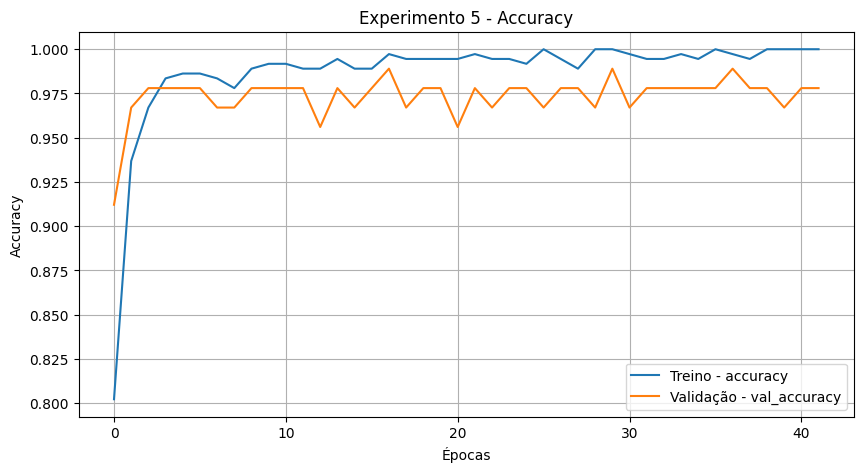

In [45]:
# ============================================================
# GRÁFICO DA ACCURACY
# ============================================================

plt.figure(figsize=(10, 5))
# Accuracy no treinamento.

plt.plot(
history_final.history["accuracy"],
label="Treino - accuracy"
)
# Accuracy na validação.

plt.plot(
history_final.history["val_accuracy"],
label="Validação - val_accuracy"
)
plt.xlabel("Épocas")
plt.ylabel("Accuracy")
plt.title(
"Experimento 5 - Accuracy"
)
plt.legend()
plt.grid()
plt.show()

# CÉLULA 65 — CÓDIGO

In [46]:
# ============================================================
# AVALIAÇÃO FINAL NO TESTe
# ============================================================

test_loss_final, test_accuracy_final = (
model_final.evaluate(
X_test,
y_test,
verbose=0
)
)
print("Loss no teste: ", test_loss_final)
print(
"Accuracy no teste: ",
test_accuracy_final
)
print(
"Accuracy no teste (%): ",
test_accuracy_final * 100
)

Loss no teste:  0.20826241374015808
Accuracy no teste:  0.9561403393745422
Accuracy no teste (%):  95.61403393745422


Melhor época: 8
Épocas executadas: 13
Menor val_loss: 0,1567
Loss no teste: 0,1815
Accuracy no teste: 95,61%

# EXPERIMENTO 6 — AJUSTE DOS HIPERPARÂMETROS DE
## GENERALIZAÇÃO

No Experimento 5 utilizamos técnicas para reduzir o overfitting: L2, Dropout e Early Stopping.

Porém, como temos apenas 569 amostras, é possível que a regularização esteja forte demais,
dificultando o aprendizado da rede.

A pergunta do novo experimento será:
“Será que estamos regularizando demais uma rede treinada com poucos dados?”

No Experimento 6 vamos diminuir a força da regularização, permitindo que a rede tenha um
pouco mais de liberdade para aprender:

text
L2: 0.001 → 0.0001 # penalização dos pesos mais leve
Dropout:
0.30 → 0.15 # desliga menos neurônios durante o treinamento
Patience: 5 → 10 # espera mais épocas antes de interromper

O objetivo é verificar se essas alterações proporcionam um equilíbrio melhor entre aprendizado
e generalização, reduzindo o risco de underfitting causado por regularização excessiva.

# CÉLULA 69 — CÓDIGO

In [47]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.regularizers import l2

# ============================================================
# FUNÇÃO PARA CRIAR A REDE NEURAL
# ============================================================

def criar_modelo(valor_l2, valor_dropout):

    # Toda vez que chamarmos esta função,
    # uma NOVA rede neural será criada.

    modelo = keras.Sequential([

        # 30 características de entrada
        layers.Input(shape=(30,)),

        # Primeira camada oculta
        layers.Dense(
            128,
            activation="relu",
            kernel_regularizer=l2(valor_l2)
        ),
        # O valor do Dropout agora será variável
        layers.Dropout(valor_dropout),

        # Segunda camada oculta
        layers.Dense(
            64,
            activation="relu",
            kernel_regularizer=l2(valor_l2)
        ),
        layers.Dropout(valor_dropout),
        # Terceira camada oculta
        layers.Dense(
            32,
            activation="relu",
            kernel_regularizer=l2(valor_l2)
        ),
        # Saída binária
        layers.Dense(
            1,
        )
    ])
    # Compilação da nova rede
    modelo.compile(
        optimizer="adam",
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )
    return modelo

# CÉLULA 70 — CÓDIGO

In [48]:
# ============================================================
# HIPERPARÂMETROS QUE SERÃO TESTADOS
# ============================================================

configuracoes = [

# L2 Dropout

(0.001, 0.30),
(0.001, 0.15),
(0.0001, 0.30),
(0.0001, 0.15)
]

# CÉLULA 71 — CÓDIGO

In [49]:
# Lista vazia onde guardaremos
# o resultado de cada experimento.

resultados_tuning = []

# CÉLULA 72 — CÓDIGO

In [50]:
# ============================================================
# TESTE AUTOMÁTICO DOS HIPERPARÂMETROS
# ============================================================

for valor_l2, valor_dropout in configuracoes:
    print("\n======================================")
    print("Testando: ")
    print("L2 = ", valor_l2)
    print("Dropout = ", valor_dropout)
    print("======================================")

    # Cria uma NOVA rede para esta combinação

    modelo_temp = criar_modelo(
        valor_l2,
        valor_dropout
    )

    # Early Stopping NOVO para cada treinamento

    early_stop_temp = keras.callbacks.EarlyStopping(

        # Observa a validação

        monitor="val_loss",

        # Quanto menor, melhor

        mode="min",

        # Espera até 10 épocas sem melhora

        patience=10,

        # Recupera os melhores pesos

        restore_best_weights=True
    )

    # Treina a rede

    history_temp = modelo_temp.fit(
        X_train,
        y_train,
        validation_data=(X_val, y_val),

        # Máximo de épocas

        epochs=200,
        batch_size=16,
        callbacks=[early_stop_temp],

        # Não mostra todas as épocas na tela
        verbose=0
    )

    # Descobre a melhor época
    melhor_epoca = (
        np.argmin(history_temp.history["val_loss"]) + 1
    )
    # Descobre o menor val_loss
    melhor_val_loss = np.min(
        history_temp.history["val_loss"]
    )
    # Quantas épocas foram realmente executadas?

    epocas_executadas = len(
        history_temp.history["loss"]
    )
    # Guarda os resultados

    resultados_tuning.append({
        "L2": valor_l2,
        "Dropout": valor_dropout,
        "Melhor época": melhor_epoca,
        "Épocas executadas": epocas_executadas,
        "Melhor val_loss": melhor_val_loss
    })


Testando: 
L2 =  0.001
Dropout =  0.3

Testando: 
L2 =  0.001
Dropout =  0.15

Testando: 
L2 =  0.0001
Dropout =  0.3

Testando: 
L2 =  0.0001
Dropout =  0.15


# CÉLULA 73 — CÓDIGO

In [51]:
# ============================================================
# TABELA COM OS RESULTADOS
# ============================================================

tabela_tuning = pd.DataFrame(
resultados_tuning
)
tabela_tuning

,L2,Dropout,Melhor época,Épocas executadas,Melhor val_loss
0,0.0010,0.30,13,23,0.377681
1,0.0010,0.15,6,16,0.237405
2,0.0001,0.30,4,14,0.072473
3,0.0001,0.15,9,19,0.210997


# CÉLULA 74 — CÓDIGO

In [52]:
# ============================================================
# MELHOR CONFIGURAÇÃO
# ============================================================
melhor_configuracao = tabela_tuning.loc[
tabela_tuning["Melhor val_loss"].idxmin()
]
print("MELHOR CONFIGURAÇÃO")
print()
print(
"L2:",
melhor_configuracao["L2"]
)
print(
"Dropout:",
melhor_configuracao["Dropout"]
)
print(
"Melhor época:",
int(melhor_configuracao["Melhor época"])
)
print(
"Melhor val_loss:",
melhor_configuracao["Melhor val_loss"]
)


MELHOR CONFIGURAÇÃO

L2: 0.0001
Dropout: 0.3
Melhor época: 4
Melhor val_loss: 0.0724727213382721



Isso sustenta a nossa hipótese de que a configuração do Experimento 5 (L2=0.001 e
Dropout=0.30) estava aplicando uma regularização mais forte do que essa busca favoreceu
para esses dados. Mas atenção: o tuning escolheu a melhor entre as quatro configurações
testadas, não necessariamente a melhor possível.
Agora falta uma etapa importante: treinar o modelo escolhido e só depois fazer a avaliação
final no Test.
```
# Isto está formatado como código
```



# CÉLULA 76 — CÓDIGO

In [53]:
# ============================================================
# CRIAR O MODELO COM OS MELHORES HIPERPARÂMETROS
# ============================================================

# Valores escolhidos pelo Hyperparameter Tuning
melhor_l2 = 0.0001
melhor_dropout = 0.15
# Criamos uma NOVA rede com a configuração vencedora
modelo_vencedor = criar_modelo(
melhor_l2,
melhor_dropout
)
modelo_vencedor.summary()

Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_36 (Dense)                │ (None, 128)            │         3,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_37 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_13 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_38 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_39 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,337 (56.00 KB)

 Trainable params: 14,337 (56.00 KB)

 Non-trainable params: 0 (0.00 B)

# CÉLULA 77 — CÓDIGO

In [54]:
# ============================================================
# EARLY STOPPING DO MODELO VENCEDOR
# ============================================================

early_stop_vencedor = keras.callbacks.EarlyStopping(

# Acompanha o erro de validação

monitor="val_loss",

# Queremos minimizar o val_loss

mode="min",

# Espera até 10 épocas sem melhora

patience=10,

# Recupera os pesos da melhor época
restore_best_weights=True
)

# CÉLULA 78 — CÓDIGO

In [55]:
# ============================================================
# TREINAMENTO DO MODELO VENCEDOR
# ============================================================

history_vencedor = modelo_vencedor.fit(

# Dados de treinamento
X_train,
y_train,

# Dados de validação
validation_data=(X_val, y_val),

# Limite máximo
epochs=200,

# Tamanho do lote
batch_size=16,

# Early Stopping
callbacks=[early_stop_vencedor]
)

Epoch 1/200
23/23 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - accuracy: 0.6346 - loss: 2.2199 - val_accuracy: 0.9451 - val_loss: 0.3208
Epoch 2/200
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9341 - loss: 0.2172 - val_accuracy: 0.9560 - val_loss: 0.2602
Epoch 3/200
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9505 - loss: 0.2293 - val_accuracy: 0.9341 - val_loss: 0.2785
Epoch 4/200
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9670 - loss: 0.1760 - val_accuracy: 0.9670 - val_loss: 0.2612
Epoch 5/200
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9753 - loss: 0.1590 - val_accuracy: 0.9780 - val_loss: 0.1169
Epoch 6/200
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9753 - loss: 0.1168 - val_accuracy: 0.9560 - val_loss: 0.2353
Epoch 7/200
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9835 - loss: 0.1048 - val_accuracy: 0.9670 - val_loss: 0.2366
Epoch 8/200
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9863 - loss: 0.0998 - val_accuracy: 0.9670 - 

# CÉLULA 79 — CÓDIGO

In [56]:
# Quantas épocas foram executadas?

epocas_vencedor = len(
history_vencedor.history["loss"]
)
# Qual apresentou o menor val_loss?
melhor_epoca_vencedor = (
np.argmin(history_vencedor.history["val_loss"]) + 1
)
menor_val_loss_vencedor = np.min(
history_vencedor.history["val_loss"]
)
print("Épocas executadas: ", epocas_vencedor)
print("Melhor época: ", melhor_epoca_vencedor)
print("Menor val_loss: ", menor_val_loss_vencedor)

Épocas executadas:  15
Melhor época:  5
Menor val_loss:  0.11687588691711426


# CÉLULA 80 — CÓDIGO

In [57]:
# ============================================================
# AVALIAÇÃO FINAL NO TEST
# ============================================================

test_loss_vencedor, test_accuracy_vencedor = (
modelo_vencedor.evaluate(
X_test,
y_test,
verbose=0
)
)
print(
"Loss no teste: ",
test_loss_vencedor
)
print(
"Accuracy no teste: ",
test_accuracy_vencedor
)
print(
"Accuracy no teste (%): ",
test_accuracy_vencedor * 100
)

Loss no teste:  0.2629212737083435
Accuracy no teste:  0.9385964870452881
Accuracy no teste (%):  93.85964870452881


Resumo dos conceitos utilizados no notebook
Época (epoch): Uma época corresponde a uma passagem completa pelos dados de
treinamento.

O parâmetro epochs=200 define o limite máximo de épocas do treinamento.


Treinamento e Generalização em Redes Neurais

random_state=42: Controla a aleatoriedade da divisão dos dados, permitindo repetir a mesma
separação em treino, validação e teste quando a mesma semente é utilizada.


model.compile(): Configura como a rede será treinada: o otimizador Adam atualiza os pesos a
partir dos gradientes; binary_crossentropy mede o erro na classificação binária; accuracy
acompanha a porcentagem de acertos.


model.fit(): Executa o treinamento usando X_train e y_train e acompanha o desempenho em
X_val e y_val.


history: Guarda os valores produzidos ao longo das épocas, como loss, accuracy, val_loss e
val_accuracy, permitindo analisar a evolução do treinamento.
L2: A regularização L2 penaliza pesos muito grandes. Em l2(0.001), o valor 0.001 controla a
intensidade da penalização: valores menores tornam a regularização mais leve.
Dropout: Desativa aleatoriamente uma fração dos neurônios durante o treinamento.

Por
exemplo, Dropout(0.30) usa taxa de 30%, enquanto Dropout(0.15) usa 15%.
Early Stopping: Interrompe o treinamento quando a métrica monitorada deixa de melhorar
durante o número de épocas definido em patience. Com restore_best_weights=True, recupera
os pesos da melhor época.


Generalização: É a capacidade do modelo de manter bom desempenho em dados que não
foram usados para ajustar seus pesos.

EXPERIMENTO 6 — AJUSTE DOS HIPERPARÂMETROS DE
# GENERALIZAÇÃO

A hipótese investigada é se a rede estava sendo regularizada em excesso para um conjunto
de apenas 569 amostras. O notebook testa combinações de L2 e Dropout e utiliza patience=10
no Early Stopping.

 A comparação automática escolhe, entre as configurações testadas, aquela
que apresenta o menor val_loss.


Comparação didática: L2 0.001 → 0.0001 torna a penalização mais leve; Dropout 0.30 → 0.15
desativa menos neurônios; patience 5 → 10 permite esperar mais épocas antes da interrupção
por ausência de melhora.